In [1]:
# Setup - Run this first!
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Define objects our system can recognize
OBJECTS = ["cup", "ball", "book", "phone", "apple"]
NUM_OBJECTS = len(OBJECTS)

print("Setup complete!")
print("Objects:", OBJECTS)


Setup complete!
Objects: ['cup', 'ball', 'book', 'phone', 'apple']


In [2]:
def create_sensory_input(true_object, num_columns, noise_level=0.3):
    """
    Creates evidence matrix for all columns.

    Parameters:
    - true_object: int, index of the actual object (0 to 4)
    - num_columns: int, number of columns to simulate
    - noise_level: float, amount of random noise (0 to 1)

    Returns:
    - evidence: numpy array of shape (num_columns, NUM_OBJECTS)
    """

    # 1. Create matrix filled with random noise
    evidence = np.random.uniform(
        low=0.0,
        high=noise_level,
        size=(num_columns, NUM_OBJECTS)
    )

    # 2. Add stronger signal for the true object
    for col in range(num_columns):
        signal = np.random.uniform(0.5, 1.0)
        evidence[col, true_object] += signal

    # 3. Normalize each row so it sums to 1
    row_sums = evidence.sum(axis=1, keepdims=True)
    evidence = evidence / row_sums

    return evidence


In [6]:
# Test create_sensory_input
true_object = 0  # "cup"
num_columns = 6

evidence = create_sensory_input(
    true_object=true_object,
    num_columns=num_columns,
    noise_level=0.3
)

print(f"True object: {OBJECTS[true_object]}")
print(f"Evidence shape: {evidence.shape}")
print("\nEach column's evidence:")

for i in range(num_columns):
    best = OBJECTS[np.argmax(evidence[i])]
    conf = np.max(evidence[i]) * 100
    print(f" Column {i}: {best} ({conf:.1f}%)")



True object: cup
Evidence shape: (6, 5)

Each column's evidence:
 Column 0: cup (55.6%)
 Column 1: cup (48.5%)
 Column 2: cup (45.0%)
 Column 3: cup (68.9%)
 Column 4: cup (75.6%)
 Column 5: cup (73.7%)


In [4]:
def initialize_beliefs(evidence):
    """Initialize beliefs from sensory evidence."""
    return evidence.copy()


In [7]:
beliefs = initialize_beliefs(evidence)

print("Beliefs initialized!")
print(f"Shape: {beliefs.shape}")
print(f"Same as evidence? {np.allclose(beliefs, evidence)}")


Beliefs initialized!
Shape: (6, 5)
Same as evidence? True


In [8]:
def voting_round(beliefs, evidence, vote_weight=0.3):
    """
    One round of voting among columns.
    """
    num_columns = beliefs.shape[0]
    new_beliefs = np.zeros_like(beliefs)

    for col in range(num_columns):
        # 1. Own contribution
        own_contribution = (1 - vote_weight) * evidence[col]

        # 2. Get other columns' beliefs
        other_indices = [i for i in range(num_columns) if i != col]
        other_beliefs = beliefs[other_indices]

        # 3. Average vote from others
        avg_vote = other_beliefs.mean(axis=0)

        # 4. Vote contribution
        vote_contribution = vote_weight * avg_vote

        # 5. Combine
        new_beliefs[col] = own_contribution + vote_contribution

    # 6. Normalize rows
    row_sums = new_beliefs.sum(axis=1, keepdims=True)
    new_beliefs = new_beliefs / row_sums

    return new_beliefs


In [9]:
print("Before voting:")
for i in range(3):
    print(
        f" Col {i}: {OBJECTS[np.argmax(beliefs[i])]} "
        f"({np.max(beliefs[i]) * 100:.1f}%)"
    )

new_beliefs = voting_round(beliefs, evidence, vote_weight=0.3)

print("\nAfter 1 voting round:")
for i in range(3):
    print(
        f" Col {i}: {OBJECTS[np.argmax(new_beliefs[i])]} "
        f"({np.max(new_beliefs[i]) * 100:.1f}%)"
    )


Before voting:
 Col 0: cup (55.6%)
 Col 1: cup (48.5%)
 Col 2: cup (45.0%)

After 1 voting round:
 Col 0: cup (57.6%)
 Col 1: cup (53.1%)
 Col 2: cup (50.8%)


In [10]:
def run_voting(
    evidence,
    max_iterations=20,
    vote_weight=0.3,
    consensus_threshold=0.9
):
    """
    Run voting until consensus or max iterations.
    Returns: history, final_object, final_confidence, iterations_used
    """

    # 1. Initialize beliefs
    beliefs = initialize_beliefs(evidence)

    # 2. Store history
    history = [beliefs.copy()]

    for iteration in range(max_iterations):
        # 3. One voting round
        beliefs = voting_round(beliefs, evidence, vote_weight)

        # 4. Save history
        history.append(beliefs.copy())

        # 5. Check consensus
        predictions = np.argmax(beliefs, axis=1)
        vote_counts = np.bincount(predictions, minlength=NUM_OBJECTS)
        most_common = vote_counts.argmax()
        agreement = (predictions == most_common).mean()

        # 6. Stop if consensus reached
        if agreement >= consensus_threshold:
            print(f"Consensus at iteration {iteration + 1}!")
            break

    # Final result
    final_votes = beliefs.mean(axis=0)
    final_object = np.argmax(final_votes)
    final_confidence = final_votes[final_object]
    iterations_used = len(history) - 1

    return history, final_object, final_confidence, iterations_used


In [11]:
np.random.seed(42)

evidence = create_sensory_input(
    true_object=0,
    num_columns=6,
    noise_level=0.3
)

history, result, confidence, iters = run_voting(evidence)

print(f"Result: {OBJECTS[result]}")
print(f"Confidence: {confidence * 100:.1f}%")
print(f"Iterations: {iters}")
print(f"Correct? {'Yes!' if result == 0 else 'No'}")


Consensus at iteration 1!
Result: cup
Confidence: 61.2%
Iterations: 1
Correct? Yes!


In [12]:
def visualize_consensus(history, true_object):
    """Visualize how consensus emerges."""

    # Average confidence per object at each iteration
    avg_confidence = np.array([h.mean(axis=0) for h in history])

    # Calculate agreement over time
    agreement_over_time = []
    for h in history:
        predictions = np.argmax(h, axis=1)
        counts = np.bincount(predictions, minlength=NUM_OBJECTS)
        agreement = counts.max() / len(predictions)
        agreement_over_time.append(agreement)

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot 1: Confidence over time
    ax1 = axes[0]
    for obj_idx in range(NUM_OBJECTS):
        if obj_idx == true_object:
            style = '-'
            width = 3
        else:
            style = '--'
            width = 1

        ax1.plot(
            avg_confidence[:, obj_idx],
            style,
            linewidth=width,
            label=OBJECTS[obj_idx]
        )

    ax1.set_xlabel("Voting Round")
    ax1.set_ylabel("Average Confidence")
    ax1.set_title("Confidence Evolution")
    ax1.legend()
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Agreement over time
    ax2 = axes[1]
    ax2.plot(agreement_over_time, 'b-', linewidth=2, marker='o')
    ax2.axhline(y=0.9, color='r', linestyle='--', label='Consensus Threshold')
    ax2.set_xlabel("Voting Round")
    ax2.set_ylabel("Column Agreement")
    ax2.set_title("Consensus Emergence")
    ax2.legend()
    ax2.set_ylim(0, 1.05)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


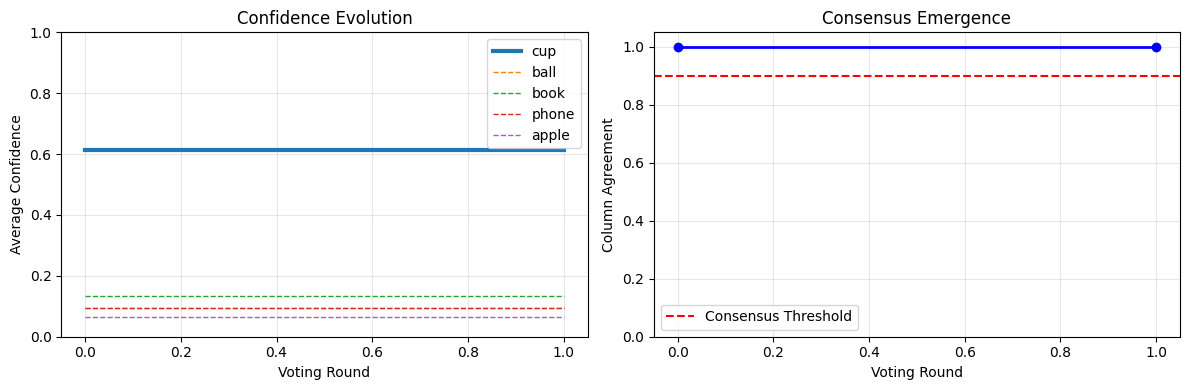

In [13]:
visualize_consensus(history, true_object=0)


EXPERIMENT 1: HIGH NOISE
Consensus at iteration 1!
Result: cup
Confidence: 42.3%
Iterations: 1
Correct? Yes


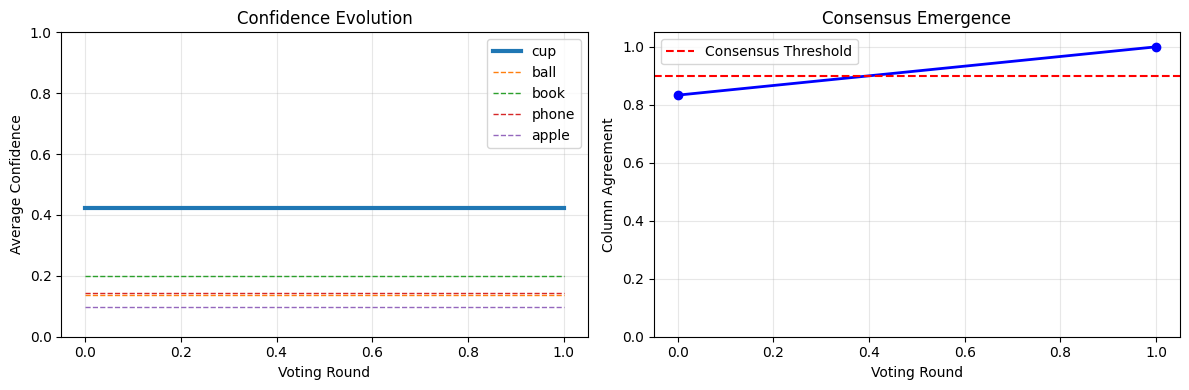

In [14]:
print("=" * 50)
print("EXPERIMENT 1: HIGH NOISE")
print("=" * 50)

np.random.seed(42)

evidence_noisy = create_sensory_input(
    true_object=0,
    num_columns=6,
    noise_level=0.8
)

history_noisy, result_noisy, conf_noisy, iters_noisy = run_voting(evidence_noisy)

print(f"Result: {OBJECTS[result_noisy]}")
print(f"Confidence: {conf_noisy * 100:.1f}%")
print(f"Iterations: {iters_noisy}")
print(f"Correct? {'Yes' if result_noisy == 0 else 'NO - WRONG ANSWER'}")

visualize_consensus(history_noisy, true_object=0)


EXPERIMENT 2: MORE COLUMNS
Consensus at iteration 1!
Result: cup
Confidence: 62.8%
Iterations: 1


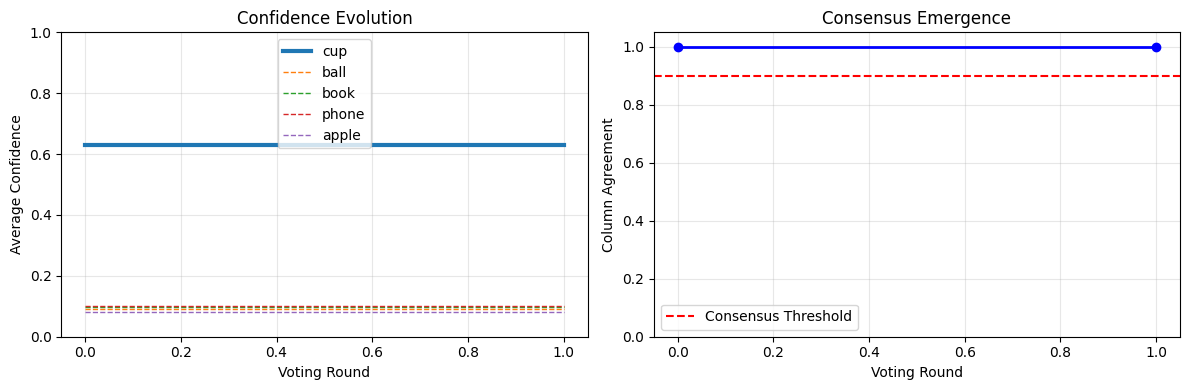

In [15]:
print("=" * 50)
print("EXPERIMENT 2: MORE COLUMNS")
print("=" * 50)

np.random.seed(42)

evidence_many = create_sensory_input(
    true_object=0,
    num_columns=20,   # Increased from 6 → 20
    noise_level=0.3
)

history_many, result_many, conf_many, iters_many = run_voting(evidence_many)

print(f"Result: {OBJECTS[result_many]}")
print(f"Confidence: {conf_many * 100:.1f}%")
print(f"Iterations: {iters_many}")

visualize_consensus(history_many, true_object=0)


In [16]:
print("=" * 50)
print("EXPERIMENT 3: VOTE WEIGHT COMPARISON")
print("=" * 50)

weights_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for w in weights_to_test:
    np.random.seed(42)
    ev = create_sensory_input(
        true_object=0,
        num_columns=6,
        noise_level=0.4
    )

    _, res, conf, iters = run_voting(ev, vote_weight=w)
    correct = "Yes" if res == 0 else "No"
    results.append((w, OBJECTS[res], conf, iters, correct))

print(f"{'Weight':<8} {'Result':<8} {'Conf':<10} {'Iters':<8} {'Correct'}")
print("-" * 45)

for w, obj, conf, iters, correct in results:
    print(f"{w:<8} {obj:<8} {conf * 100:>5.1f}% {iters:<8} {correct}")


EXPERIMENT 3: VOTE WEIGHT COMPARISON
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Weight   Result   Conf       Iters    Correct
---------------------------------------------
0.1      cup       55.4% 1        Yes
0.3      cup       55.4% 1        Yes
0.5      cup       55.4% 1        Yes
0.7      cup       55.4% 1        Yes
0.9      cup       55.4% 1        Yes


# Analysis & Reflection  
**L02 – Cortical Column Voting Simulation**


5.1 Experiment Analysis
Question 1: Effects of Noise (Experiment 1 – High Noise)

When the noise level was increased to 0.8, the system still correctly identified the true object (“cup”), but overall confidence dropped noticeably compared to the low-noise condition. Under low noise (0.3), confidence was around 60%, whereas under high noise it fell to roughly 42%. This demonstrates that while the voting system is robust to noise in terms of accuracy, noise directly impacts certainty.

Noise makes consensus harder because each cortical column receives more corrupted and ambiguous sensory input. Individual columns are less confident in their local evidence, so even when they agree, the shared belief is weaker. Despite this, the system still converged quickly, suggesting that distributed voting provides robustness against uncertainty. This mirrors biological perception, where noisy sensory input does not necessarily prevent correct perception, but does reduce confidence and reliability.

Question 2: Number of Columns (Experiment 2 – More Columns)

Increasing the number of columns from 6 to 20 resulted in slightly higher confidence while maintaining rapid convergence. The result remained correct, and confidence increased marginally (from ~61% to ~63%). Although the improvement was modest in this low-noise scenario, it highlights the averaging effect of distributed representations.

With more columns, random noise and local errors are averaged out across many independent estimates. This directly relates to the brain’s approximately 150,000 cortical columns: massive redundancy enables stable perception even when individual columns are unreliable. A potential downside of having many columns is increased computational and communication cost, which in biological systems is addressed through sparse and local connectivity rather than global communication.

Question 3: Vote Weight Trade-off (Experiment 3)

Across vote_weight values from 0.1 to 0.9, the system consistently converged in one iteration with similar confidence. This occurred because the initial sensory evidence was strong enough to trigger immediate consensus, leaving little opportunity for vote_weight to influence later dynamics.

Conceptually, vote_weight controls a trade-off between individual evidence and collective agreement. Very low values (e.g., 0.1) represent columns acting mostly independently, which can slow convergence in noisy conditions. Very high values (e.g., 0.9) risk amplifying early mistakes by over-trusting neighbors. Mid-range values best balance stability and flexibility, illustrating a general principle in distributed systems: effective intelligence requires balancing local evidence with shared information.

5.2 Connection to Neuroscience
Question 4: Distributed Representation

In this simulation, no single column ever “knows” the correct answer on its own. Instead, correct perception emerges from agreement across many columns, which directly reflects the Thousand Brains Theory. Each column maintains a partial, local model of the world, and intelligence arises through coordination rather than central control.

If only one column were used, the system would be extremely fragile and highly sensitive to noise. The brain likely uses distributed representations to achieve robustness, adaptability, and fault tolerance, avoiding reliance on a single decision-making center.

Question 5: Lateral Connections

The voting mechanism simulates lateral connections between cortical columns. These connections allow columns to share beliefs and reduce uncertainty by pooling information. If vote_weight were set to zero, columns would never communicate, and consensus would depend entirely on individual evidence, making the system much less reliable.

In the real brain, lateral connections allow columns to reconcile conflicting information, stabilize perception, and build coherent interpretations of sensory input across space and time.

5.3 Limitations of the Model
Our Simulation	Real Cortical Columns	Why It Matters
6–20 columns	~150,000 columns	The brain benefits from massive redundancy and fault tolerance
Simple probability vectors	~100,000 neurons per column	Real columns perform complex nonlinear computations
All columns connected	Sparse local connectivity	Prevents runaway consensus and reduces energy cost
No reference frames	Grid-cell–based reference frames	Real perception is grounded in sensorimotor context
Static input	Temporal sequences	Real cognition unfolds over time
Pre-defined objects	Continuous learning	The brain learns new concepts dynamically
Question 6: Model Validity

This simulation captures key high-level principles of cortical processing, including distributed representation, consensus through voting, and robustness to noise. However, it omits many critical biological features such as temporal dynamics, hierarchical processing, learning, and detailed neuronal interactions.

As a result, this model should not be trusted to make quantitative predictions about real neural behavior. Instead, it is best viewed as a conceptual and educational model that illustrates why distributed architectures are powerful, rather than how the brain implements them in detail.